# Task 2 — Notebook 03: Threshold sensitivity + classification + GeoTIFFs

1. **Sensitivity sweep:** grid over `(alternation_min × pattern_dist_max)` with **YAML `min_years_in_cornsoy` and monoculture rules fixed** — table, CSV, and line chart (% regular vs `alternation_min`, one line per `dist_max`). This is *threshold calibration* (NAFSI-style), not a change to the primary rule.  
2. **Primary classification:** strict thresholds from `configs/task2_crop_rotation.yaml` → `rotation_class_map.tif`, smoothed GeoTIFF, and `rotation_metrics_classified.parquet` for downstream maps and areal stats.

**Orthogonality (from the sensitivity CSV):** `pct_monoculture` is **constant** across all 20 `(alternation_min, pattern_dist_max)` combinations — e.g. **26.46%** on this run — because the monoculture rule uses **only** `max_run_length` and `crop_share`, which do **not** depend on alternation or pattern-distance thresholds. Regular vs irregular shares move; monoculture is a **stable anchor** measuring persistence, not sequence match to the canonical C–S template.


pattern_dist_max      3      4      5      6
alternation_min                             
0.50              20.20  33.58  41.56  44.32
0.55              20.10  33.13  40.50  42.71
0.60              18.30  28.11  34.61  36.76
0.65              18.17  27.65  33.54  35.35
0.70              16.48  20.79  24.94  26.34
Wrote artifacts\tables\task2\task2__threshold_sensitivity_grid.csv


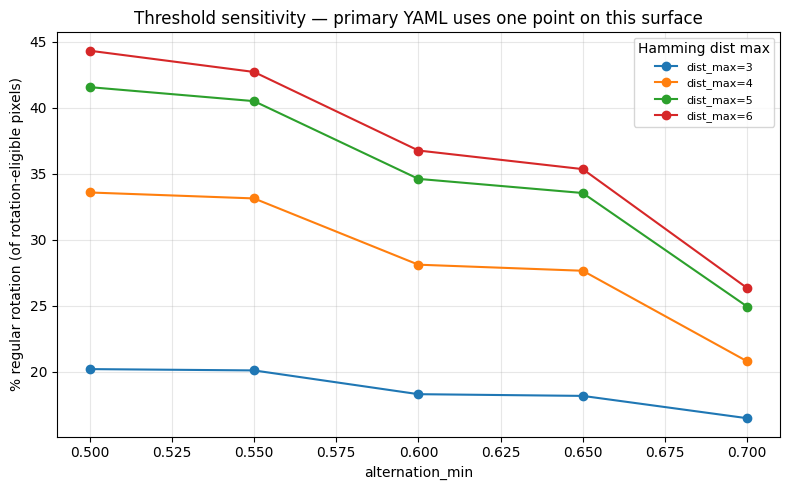

In [3]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

_cwd = Path.cwd().resolve()
REPO_ROOT = next(
    (p for p in (_cwd, *_cwd.parents) if (p / "requirements.txt").is_file() and (p / "src").is_dir()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not find repo root.")
sys.path.insert(0, str(REPO_ROOT))

from src.modeling.rotation_classifier import classify_batch

with open(REPO_ROOT / "configs" / "task2_crop_rotation.yaml", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

th = cfg["classification"]
reg = th["regular_rotation_threshold"]
mono = th["monoculture_threshold"]
cs_min = int(reg["min_years_in_cornsoy"])
mono_run = int(mono["max_run_min"])
mono_share = 0.80

metrics_df = pd.read_parquet(REPO_ROOT / cfg["output"]["processed_dir"] / "rotation_metrics.parquet")
alt_a = metrics_df["alternation_score"].to_numpy()
run_a = metrics_df["max_run_length"].to_numpy()
dist_a = metrics_df["pattern_edit_distance"].to_numpy()
ncs_a = metrics_df["n_cornsoy_years"].to_numpy()
share_a = metrics_df["crop_share"].to_numpy()

alt_grid = [0.50, 0.55, 0.60, 0.65, 0.70]
dist_grid = [3, 4, 5, 6]
rows = []
for dist_max in dist_grid:
    for alt_min in alt_grid:
        cls = classify_batch(
            alt_a, run_a, dist_a, ncs_a, share_a,
            alt_min=float(alt_min), dist_max=int(dist_max), cs_min=cs_min,
            mono_run=mono_run, mono_share=mono_share,
        )
        n = len(cls)
        rows.append({
            "alternation_min": alt_min,
            "pattern_dist_max": dist_max,
            "pct_regular": round(100.0 * float(np.sum(cls == 0)) / n, 2),
            "pct_monoculture": round(100.0 * float(np.sum(cls == 1)) / n, 2),
            "pct_irregular": round(100.0 * float(np.sum(cls == 2)) / n, 2),
            "n_pixels": n,
        })
sens = pd.DataFrame(rows)
try:
    print(sens.pivot_table(index="alternation_min", columns="pattern_dist_max", values="pct_regular"))
except Exception:
    print(sens)

tbl_dir = REPO_ROOT / cfg["output"]["tables_dir"]
tbl_dir.mkdir(parents=True, exist_ok=True)
sens_path = tbl_dir / "task2__threshold_sensitivity_grid.csv"
sens.to_csv(sens_path, index=False)
print("Wrote", sens_path.relative_to(REPO_ROOT))

fig, ax = plt.subplots(figsize=(8, 5))
for dm in dist_grid:
    sub = sens[sens["pattern_dist_max"] == dm].sort_values("alternation_min")
    ax.plot(sub["alternation_min"], sub["pct_regular"], marker="o", label=f"dist_max={dm}")
ax.set_xlabel("alternation_min")
ax.set_ylabel("% regular rotation (of rotation-eligible pixels)")
ax.set_title("Threshold sensitivity — primary YAML uses one point on this surface")
ax.legend(title="Hamming dist max", fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig_dir = REPO_ROOT / cfg["output"]["figures_dir"]
fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_dir / "task2__threshold_sensitivity_regular_pct.png", dpi=200, bbox_inches="tight")
plt.show()


In [4]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
import yaml
from rasterio.crs import CRS

_cwd = Path.cwd().resolve()
REPO_ROOT = next(
    (p for p in (_cwd, *_cwd.parents) if (p / "requirements.txt").is_file() and (p / "src").is_dir()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not find repo root.")
sys.path.insert(0, str(REPO_ROOT))

from rasterio.transform import Affine
from src.io.cdl_parquet import load_cdl_spatial_metadata
from src.modeling.rotation_classifier import classify_batch, majority_smooth_classes

with open(REPO_ROOT / "configs" / "task2_crop_rotation.yaml", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

th = cfg["classification"]
reg = th["regular_rotation_threshold"]
mono = th["monoculture_threshold"]
alt_min = float(reg["alternation_score_min"])
dist_max = int(reg["pattern_distance_max"])
cs_min = int(reg["min_years_in_cornsoy"])
mono_run = int(mono["max_run_min"])
mono_share = 0.80

metrics_df = pd.read_parquet(REPO_ROOT / cfg["output"]["processed_dir"] / "rotation_metrics.parquet")
cls_arr = classify_batch(
    metrics_df["alternation_score"].to_numpy(),
    metrics_df["max_run_length"].to_numpy(),
    metrics_df["pattern_edit_distance"].to_numpy(),
    metrics_df["n_cornsoy_years"].to_numpy(),
    metrics_df["crop_share"].to_numpy(),
    alt_min=alt_min,
    dist_max=dist_max,
    cs_min=cs_min,
    mono_run=mono_run,
    mono_share=mono_share,
)
metrics_df["rotation_class"] = cls_arr

meta = load_cdl_spatial_metadata(REPO_ROOT)
H, W = int(meta["height"]), int(meta["width"])
tlist = meta["transform"]
transform = Affine(tlist[0], tlist[1], tlist[2], tlist[3], tlist[4], tlist[5])
crs = CRS.from_string(meta["crs"]) if meta.get("crs") else None

raster = np.full((H, W), 255, dtype=np.uint8)
raster[metrics_df["iy"].to_numpy(), metrics_df["ix"].to_numpy()] = metrics_df["rotation_class"].to_numpy(
    dtype=np.uint8
)

out_dir = REPO_ROOT / cfg["output"]["processed_dir"]
out_dir.mkdir(parents=True, exist_ok=True)
raw_tif = out_dir / "rotation_class_map.tif"
with rasterio.open(
    raw_tif,
    "w",
    driver="GTiff",
    height=H,
    width=W,
    count=1,
    dtype="uint8",
    crs=crs,
    transform=transform,
    nodata=255,
) as dst:
    dst.write(raster, 1)

if cfg.get("spatial_smoothing", {}).get("enabled", True):
    sm = majority_smooth_classes(raster, nodata=255, kernel=int(cfg["spatial_smoothing"]["kernel_size"]))
else:
    sm = raster
sm_tif = out_dir / "rotation_class_map_smoothed.tif"
with rasterio.open(
    sm_tif,
    "w",
    driver="GTiff",
    height=H,
    width=W,
    count=1,
    dtype="uint8",
    crs=crs,
    transform=transform,
    nodata=255,
) as dst:
    dst.write(sm, 1)

for name, arr in ("raw", raster), ("smoothed", sm):
    vc = pd.Series(arr.flatten()).replace(255, np.nan).dropna().value_counts(normalize=True)
    print(name, vc.to_dict())

metrics_out = out_dir / "rotation_metrics_classified.parquet"
metrics_df.to_parquet(metrics_out, index=False)
print("Primary YAML thresholds:", {"alternation_min": alt_min, "pattern_dist_max": dist_max, "cs_min": cs_min})
print("Wrote:", raw_tif.relative_to(REPO_ROOT), sm_tif.relative_to(REPO_ROOT))


raw {2.0: 0.5705789674444831, 1.0: 0.264620130354744, 0.0: 0.16480090220077284}
smoothed {2.0: 0.551725624823789, 1.0: 0.2755294624939881, 0.0: 0.172744912682223}
Primary YAML thresholds: {'alternation_min': 0.7, 'pattern_dist_max': 3, 'cs_min': 7}
Wrote: data\processed\task2\rotation_class_map.tif data\processed\task2\rotation_class_map_smoothed.tif
